<a href="https://colab.research.google.com/github/jiyeonlee-2930/DeepLearning-TensorFlow-Basic/blob/main/6_1_fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 환경 설정

In [1]:
# 라이브러리 설정
import pandas as pd
import numpy as np
import tensorflow as tf
import random

# 랜덤 시드 고정
SEED=12
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
##
import tensorflow as tf
import numpy as np
import pandas as pd

# 데이터 로드
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# /content/ 에 저장
np.savez('/content/fashion_mnist.npz',
         x_train=x_train, y_train=y_train,
         x_test=x_test, y_test=y_test)

print("저장 완료! → /content/fashion_mnist.npz")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
저장 완료! → /content/fashion_mnist.npz


In [3]:
data = np.load('/content/fashion_mnist.npz')
x_train = data['x_train']  # (60000, 28, 28)
y_train = data['y_train']  # (60000,)
x_test = data['x_test']    # (10000, 28, 28)
y_test = data['y_test']    # (10000,)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

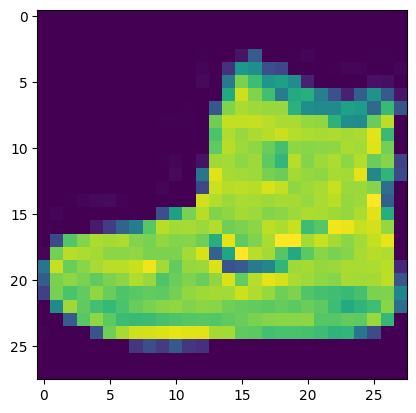

In [4]:
# 첫번째 이미지 출력
import matplotlib.pyplot as plt
plt.imshow(x_train[0]);

In [5]:
# 목표 레이블
y_train[:5]

array([9, 0, 0, 3, 0], dtype=uint8)

In [6]:
# 숫자 레이블을 실제 레이블과 연결하여 확인
target_values = {0 : 'T-shirt/top',
                 1 : 'Trouser',
                 2: 'Pullover',
                 3: 'Dress',
                 4: 'Coat',
                 5: 'Sandal',
                 6: 'Shirt',
                 7: 'Sneaker',
                 8: 'Bag',
                 9: 'Ankle boot'}
print(y_train[0])
print(target_values[y_train[0]])

9
Ankle boot


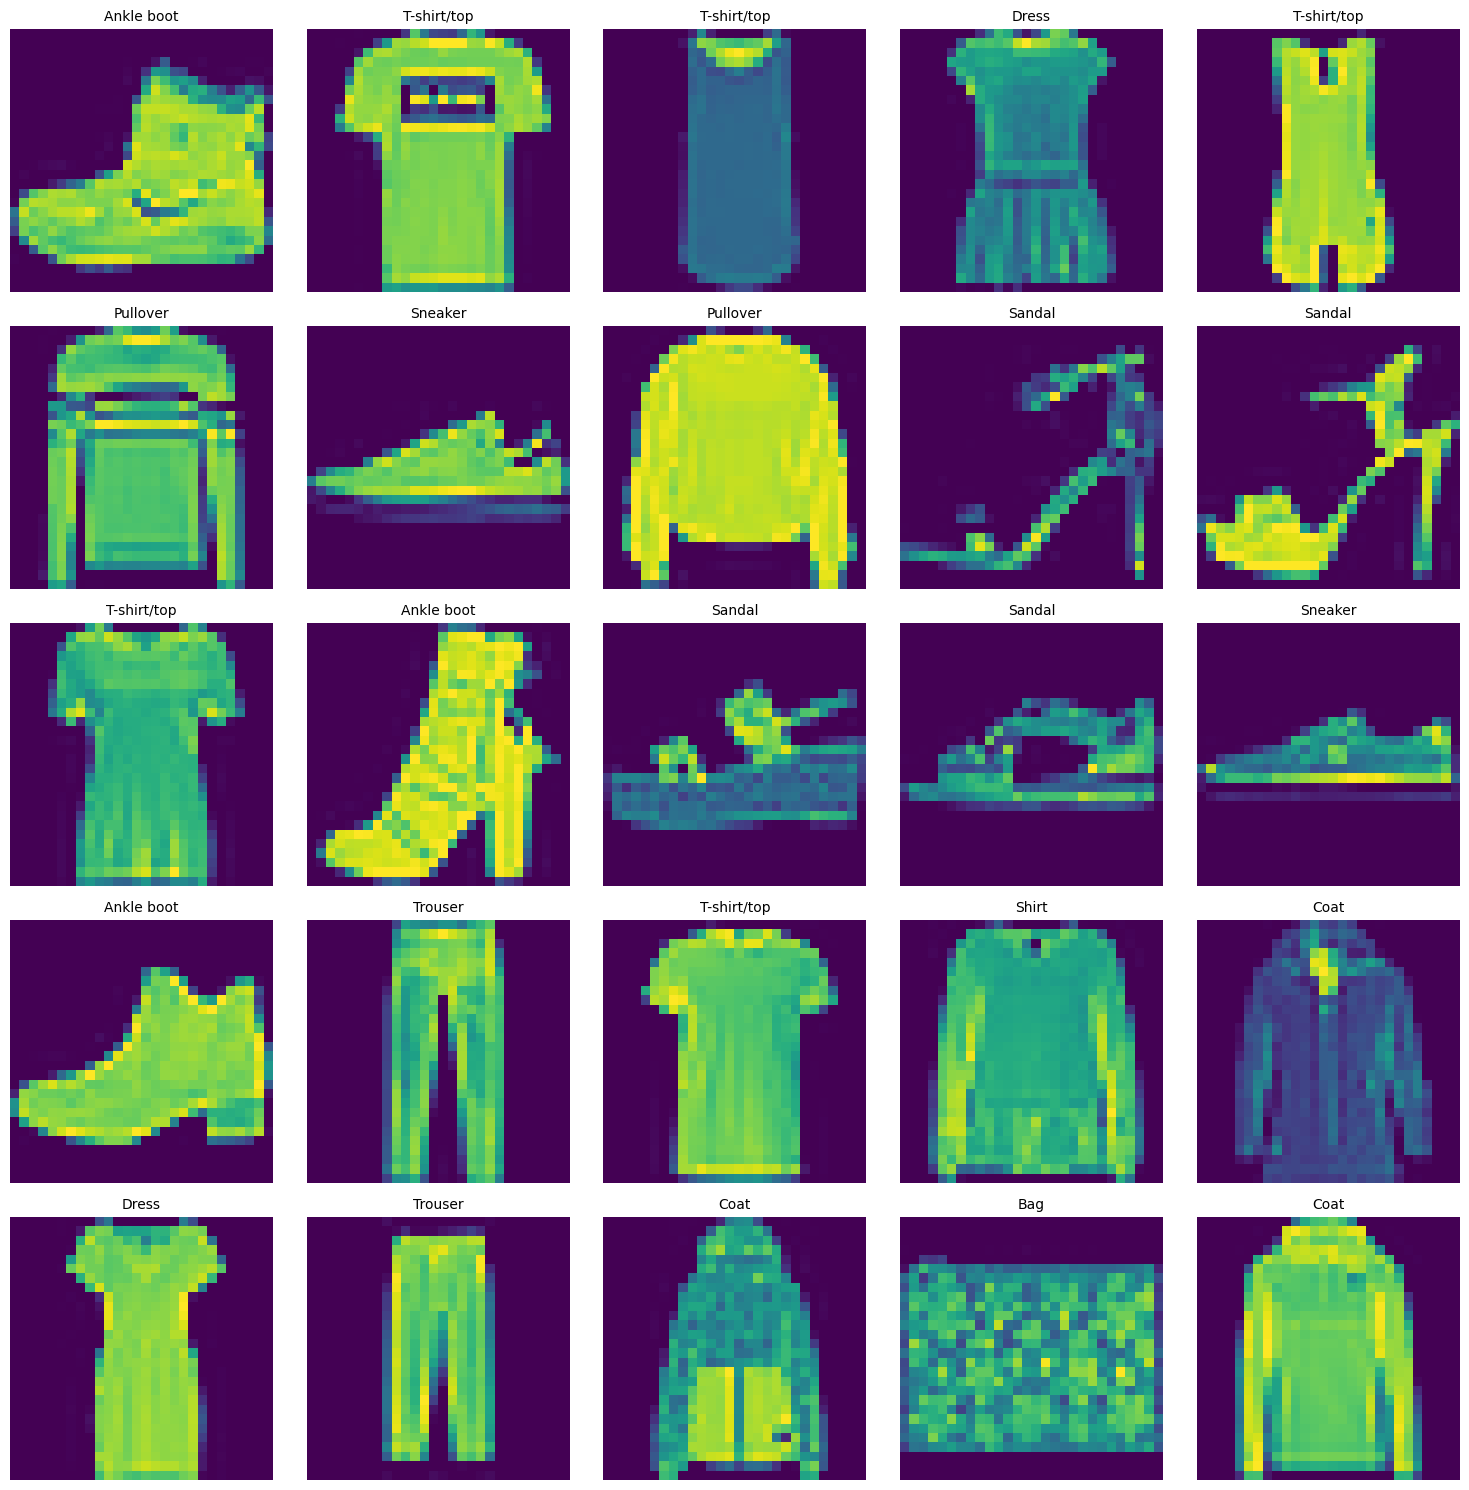

In [7]:
plt.figure(figsize=(15, 15))

for i in range(25):  # 5행 5열 = 25개
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(target_values[y_train[i]], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

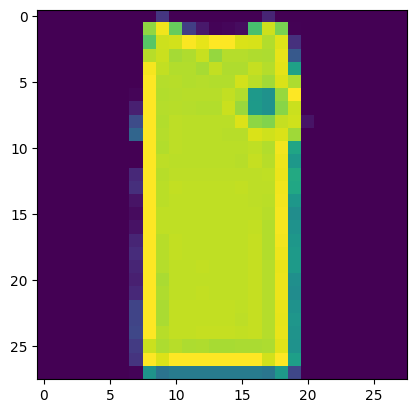

In [8]:
# 500번째 test 이미지를 출력
plt.imshow(x_test[499]);

# 2. 데이터 전처리 (Pre-processing)

In [9]:
# 피처 스케일 맞추기
X_train = x_train / 255.
X_test = x_test / 255.
print("최소값:", X_train[0].min())
print("최대값:", X_train[0].max())

최소값: 0.0
최대값: 1.0


In [10]:
# 채널 차원 추가
print("변환 전:", X_train.shape, X_test.shape)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
print("변환 후:", X_train.shape, X_test.shape)

변환 전: (60000, 28, 28) (10000, 28, 28)
변환 후: (60000, 28, 28, 1) (10000, 28, 28, 1)


In [11]:
# Train - Validation 데이터 구분
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val =  train_test_split(X_train, y_train, test_size=0.2,
                                             stratify=y_train,
                                             shuffle=True, random_state=SEED)
print("학습 데이터셋 크기: ", X_tr.shape, y_tr.shape)
print("검증 데이터셋 크기: ", X_val.shape, y_val.shape)

학습 데이터셋 크기:  (48000, 28, 28, 1) (48000,)
검증 데이터셋 크기:  (12000, 28, 28, 1) (12000,)


# 3. 모델 구축

### MLP 모델

In [12]:
# keras를 독립적으로 임포트
import keras
from keras.models import Sequential
from keras.layers import Flatten, Dense, Conv2D

mlp_model = Sequential()
mlp_model.add(Flatten(input_shape=[28, 28]))
mlp_model.add(Dense(units=64, activation='relu'))
mlp_model.add(Dense(units=10, activation='softmax'))

mlp_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['acc'])

mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
mlp_history = mlp_model.fit(X_tr, y_tr, batch_size=64, epochs=20,
                        validation_data=(X_val, y_val),
                        verbose=2)

Epoch 1/20
750/750 - 6s - 8ms/step - acc: 0.8091 - loss: 0.5609 - val_acc: 0.8368 - val_loss: 0.4623
Epoch 2/20
750/750 - 7s - 9ms/step - acc: 0.8554 - loss: 0.4119 - val_acc: 0.8492 - val_loss: 0.4233
Epoch 3/20
750/750 - 3s - 3ms/step - acc: 0.8673 - loss: 0.3749 - val_acc: 0.8512 - val_loss: 0.4092
Epoch 4/20
750/750 - 2s - 3ms/step - acc: 0.8758 - loss: 0.3489 - val_acc: 0.8544 - val_loss: 0.3983
Epoch 5/20
750/750 - 3s - 3ms/step - acc: 0.8824 - loss: 0.3290 - val_acc: 0.8573 - val_loss: 0.3912
Epoch 6/20
750/750 - 2s - 3ms/step - acc: 0.8885 - loss: 0.3121 - val_acc: 0.8597 - val_loss: 0.3814
Epoch 7/20
750/750 - 2s - 3ms/step - acc: 0.8927 - loss: 0.2988 - val_acc: 0.8623 - val_loss: 0.3754
Epoch 8/20
750/750 - 2s - 3ms/step - acc: 0.8961 - loss: 0.2877 - val_acc: 0.8643 - val_loss: 0.3673
Epoch 9/20
750/750 - 3s - 3ms/step - acc: 0.8988 - loss: 0.2783 - val_acc: 0.8672 - val_loss: 0.3611
Epoch 10/20
750/750 - 2s - 3ms/step - acc: 0.9019 - loss: 0.2694 - val_acc: 0.8703 - val_lo

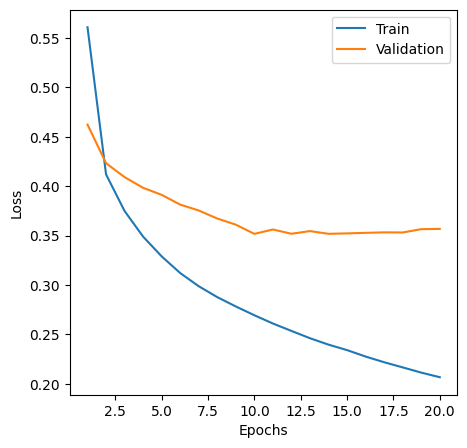

In [14]:
# 손실 함수 그래프
def plot_loss_curve(history, total_epoch=10, start=1):
    plt.figure(figsize=(5, 5))
    plt.plot(range(start, total_epoch + 1),
             history.history['loss'][start-1:total_epoch],
             label='Train')
    plt.plot(range(start, total_epoch + 1),
             history.history['val_loss'][start-1:total_epoch],
             label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_loss_curve(history=mlp_history, total_epoch=20, start=1)

### CNN 활용

In [15]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential()
cnn_model.add(Conv2D(filters=16, kernel_size=(3, 3),
                    activation='relu', input_shape=[28, 28, 1]))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(units=64, activation='relu'))
cnn_model.add(Dense(units=10, activation='softmax'))

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['acc'])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       173,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,930 (679.41 KB)

 Trainable params: 173,930 (679.41 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
cnn_history = cnn_model.fit(X_tr, y_tr, batch_size=64, epochs=20,
                        validation_data=(X_val, y_val),
                        verbose=2)

Epoch 1/20
750/750 - 8s - 11ms/step - acc: 0.8282 - loss: 0.4901 - val_acc: 0.8503 - val_loss: 0.4084
Epoch 2/20
750/750 - 3s - 4ms/step - acc: 0.8821 - loss: 0.3316 - val_acc: 0.8668 - val_loss: 0.3599
Epoch 3/20
750/750 - 4s - 6ms/step - acc: 0.8981 - loss: 0.2858 - val_acc: 0.8802 - val_loss: 0.3300
Epoch 4/20
750/750 - 2s - 3ms/step - acc: 0.9076 - loss: 0.2560 - val_acc: 0.8874 - val_loss: 0.3118
Epoch 5/20
750/750 - 2s - 3ms/step - acc: 0.9146 - loss: 0.2326 - val_acc: 0.8892 - val_loss: 0.3042
Epoch 6/20
750/750 - 3s - 4ms/step - acc: 0.9226 - loss: 0.2134 - val_acc: 0.8903 - val_loss: 0.3004
Epoch 7/20
750/750 - 3s - 4ms/step - acc: 0.9288 - loss: 0.1967 - val_acc: 0.8903 - val_loss: 0.3012
Epoch 8/20
750/750 - 2s - 3ms/step - acc: 0.9352 - loss: 0.1819 - val_acc: 0.8918 - val_loss: 0.3034
Epoch 9/20
750/750 - 2s - 3ms/step - acc: 0.9404 - loss: 0.1672 - val_acc: 0.8950 - val_loss: 0.3043
Epoch 10/20
750/750 - 2s - 3ms/step - acc: 0.9454 - loss: 0.1541 - val_acc: 0.8975 - val_l

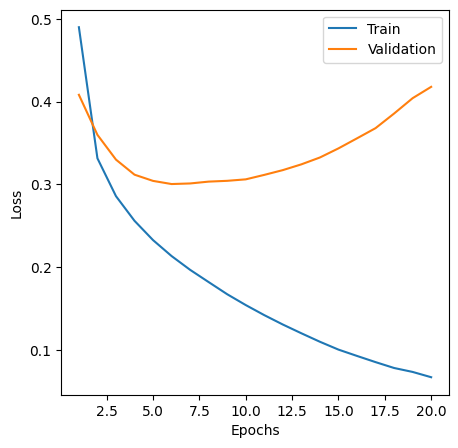

In [17]:
plot_loss_curve(history=cnn_history, total_epoch=20, start=1)

In [18]:
from keras.layers import Dropout

def build_cnn():
    model = Sequential()
    model.add(Conv2D(filters=16, kernel_size=(3, 3),
                     activation='relu', input_shape=[28, 28, 1]))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(units=64, activation='relu'))
    model.add(Dropout(rate=0.5))
    model.add(Dense(units=10, activation='softmax'))

    model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['acc'])

    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       173,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,930 (679.41 KB)

 Trainable params: 173,930 (679.41 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss',  patience=10)

cnn_history = cnn_model.fit(X_tr, y_tr, batch_size=64, epochs=100,
                        validation_data=(X_val, y_val),
                        callbacks=[early_stopping],
                        verbose=0)

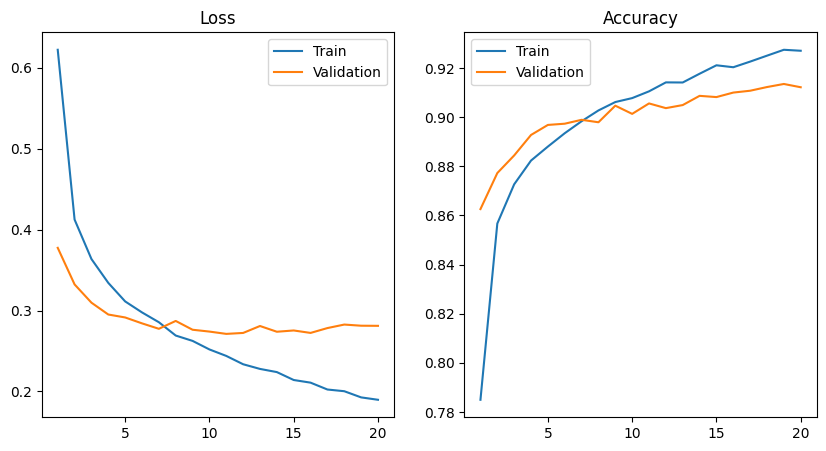

In [20]:
# 20 epoch 까지 손실함수와 정확도를 그래프로 나타내기
start=1
end = 20

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(range(start, end+1), cnn_history.history['loss'][start-1:end],
             label='Train')
axes[0].plot(range(start, end+1), cnn_history.history['val_loss'][start-1:end],
             label='Validation')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(range(start, end+1), cnn_history.history['acc'][start-1:end],
             label='Train')
axes[1].plot(range(start, end+1), cnn_history.history['val_acc'][start-1:end],
             label='Validation')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.show()

In [21]:
cnn_model.evaluate(X_val, y_val)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9118 - loss: 0.2819


[0.281851589679718, 0.9117500185966492]

In [22]:
y_pred_proba = cnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_proba, axis=-1)
y_pred_classes[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [23]:
# 1. DataFrame 생성 + predict 열 추가
submission_df = pd.DataFrame({
    'index'  : range(len(y_test)),
    'label'  : y_test,
    'predict': y_pred_classes
})

In [24]:
# 2. 예측 점수 출력
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"예측 정확도: {accuracy * 100:.2f}%")
print(submission_df.head(10))

예측 정확도: 90.68%
   index  label  predict
0      0      9        9
1      1      2        2
2      2      1        1
3      3      1        1
4      4      6        6
5      5      1        1
6      6      4        4
7      7      6        6
8      8      5        5
9      9      7        7


In [25]:
# 사용자 정의 콜백 함수
from keras.callbacks import Callback

class my_callback(Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('val_acc') > 0.91): ##사용자 정의
      self.model.stop_training = True
      print("\n")
      print("목표 정확도 달성: 검증 정확도 %.4f" % logs.get('val_acc'))

my_callback = my_callback()

# Best Model 저장
from keras.callbacks import ModelCheckpoint

best_model_path = '/content/best_cnn_model.h5'
save_best_model = ModelCheckpoint(best_model_path, monitor='val_loss',
                                  save_best_only=True, save_weights_only=False)

# CNN 모델 학습
cnn_model = build_cnn()
cnn_history = cnn_model.fit(X_tr, y_tr, batch_size=64, epochs=100,
                        validation_data=(X_val, y_val),
                        callbacks=[my_callback, save_best_model],
                        verbose=2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100


750/750 - 6s - 8ms/step - acc: 0.7683 - loss: 0.6651 - val_acc: 0.8562 - val_loss: 0.3977
Epoch 2/100


750/750 - 3s - 3ms/step - acc: 0.8441 - loss: 0.4491 - val_acc: 0.8715 - val_loss: 0.3488
Epoch 3/100


750/750 - 2s - 3ms/step - acc: 0.8619 - loss: 0.3948 - val_acc: 0.8811 - val_loss: 0.3234
Epoch 4/100


...

750/750 - 2s - 3ms/step - acc: 0.8877 - loss: 0.3125 - val_acc: 0.8950 - val_loss: 0.2885
Epoch 8/100


750/750 - 2s - 3ms/step - acc: 0.8923 - loss: 0.3004 - val_acc: 0.8977 - val_loss: 0.2835
Epoch 9/100


750/750 - 2s - 3ms/step - acc: 0.8962 - loss: 0.2918 - val_acc: 0.8995 - val_loss: 0.2794
Epoch 10/100


750/750 - 2s - 3ms/step - acc: 0.8987 - loss: 0.2806 - val_acc: 0.9007 - val_loss: 0.2767
Epoch 11/100


750/750 - 3s - 4ms/step - acc: 0.9018 - loss: 0.2699 - val_acc: 0.9020 - val_loss: 0.2736
Epoch 12/100
750/750 - 2s - 3ms/step - acc: 0.9042 - loss: 0.2621 - val_acc: 0.9057 - val_loss: 0.2739
Epoch 13/100
750/750 - 2s - 3ms/step - acc: 0.9062 - loss: 0.2553 - val_acc: 0.9062 - val_loss: 0.2754
Epoch 14/100
750/750 - 2s - 3ms/step - acc: 0.9071 - loss: 0.2486 - val_acc: 0.9032 - val_loss: 0.2791
Epoch 15/100
750/750 - 2s - 3ms/step - acc: 0.9094 - loss: 0.2439 - val_acc: 0.9074 - val_loss: 0.2775
Epoch 16/100
750/750 - 3s - 4ms/step - acc: 0.9124 - loss: 0.2371 - val_acc: 0.9060 - val_loss: 0.2760
Epoch 17/100
750/750 - 5s - 6ms/step - acc: 0.9140 - loss: 0.2290 - val_acc: 0.9053 - val_loss: 0.2800
Epoch 18/100
750/750 - 2s - 3ms/step - acc: 0.9165 - loss: 0.2269 - val_acc: 0.9068 - val_loss: 0.2822
Epoch 19/100
750/750 - 2s - 3ms/step - acc: 0.9168 - loss: 0.2212 - val_acc: 0.9080 - val_loss: 0.2743
Epoch 20/100
750/750 - 3s - 4ms/step - acc: 0.9195 - loss: 0.2128 - val_acc: 0.9082 - 

In [26]:
from keras.models import load_model
# ModelCheckPoint에 저장해둔 모델을 로딩
best_model = load_model('/content/best_cnn_model.h5')
best_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       173,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,932 (679.43 KB)

 Trainable params: 173,930 (679.41 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

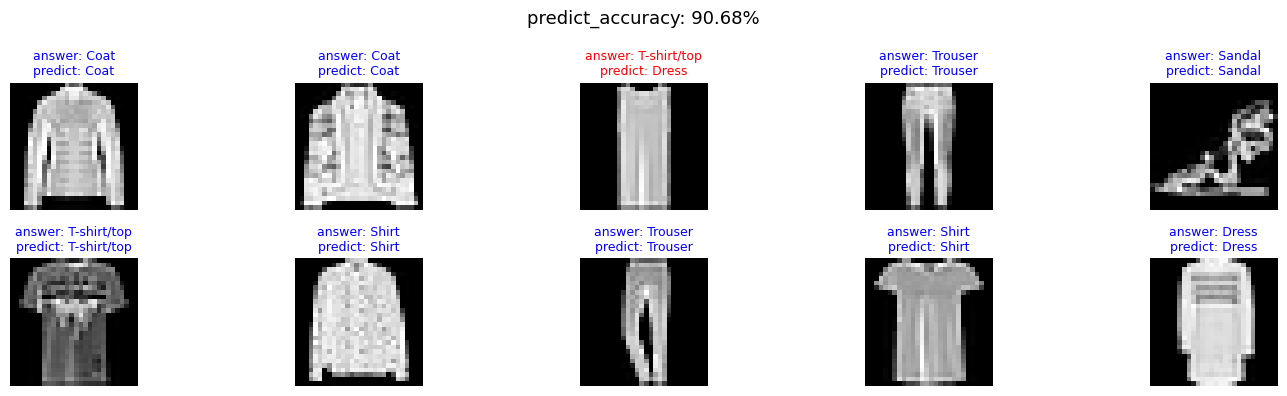

In [27]:
# 랜덤 이미지 10개 선택
indices = np.random.choice(len(x_test), 10, replace=False)

plt.figure(figsize=(15, 4))

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx], cmap='gray')

    true_label    = target_values[y_test[idx]]
    predict_label = target_values[y_pred_classes[idx]]

    # 정답이면 파란색, 틀리면 빨간색
    color = 'blue' if y_test[idx] == y_pred_classes[idx] else 'red'

    plt.title(f'answer: {true_label}\npredict: {predict_label}', color=color, fontsize=9)
    plt.axis('off')

plt.suptitle(f'predict_accuracy: {accuracy * 100:.2f}%', fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
y_pred_proba = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_proba, axis=-1)
submission_df['label'] = y_pred_classes
submission_filepath = '/content/mnist_cnn_submission2.csv'
submission_df.to_csv(submission_filepath, index=False)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
